In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.special import logsumexp
from matplotlib import gridspec


In [2]:

def crop_by_threshold(A, val, pad=1):
    """
    Returns subarray that contains all entries >= val.
    Everything outside the returned subarray is guaranteed < val.

    pad: optional extra margin (in pixels) to keep around the box.
    """
    A = np.asarray(A)
    mask = A >= val

    if A.ndim != 2:
        cols = np.where(mask)[0]
        return cols[0], cols[-1]

    if mask.all():
        return (0, A.shape[0] - 1, 0, A.shape[1] - 1)

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]

    # optional padding, clipped to bounds
    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(A.shape[0] - 1, r1 + pad)
    c1 = min(A.shape[1] - 1, c1 + pad)

    return r0, r1, c0, c1


/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/1036798997.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resul

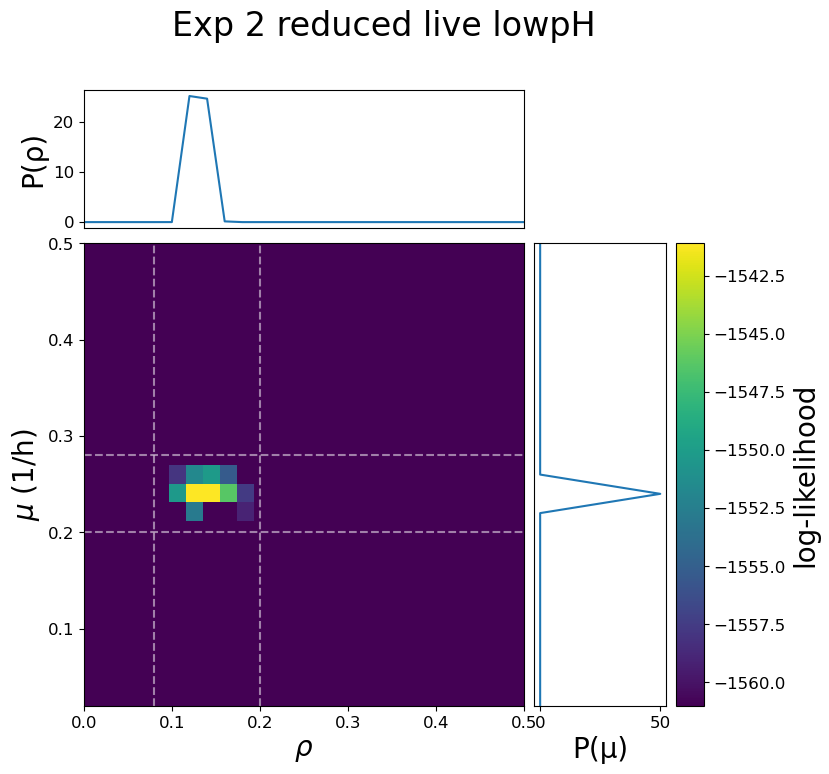

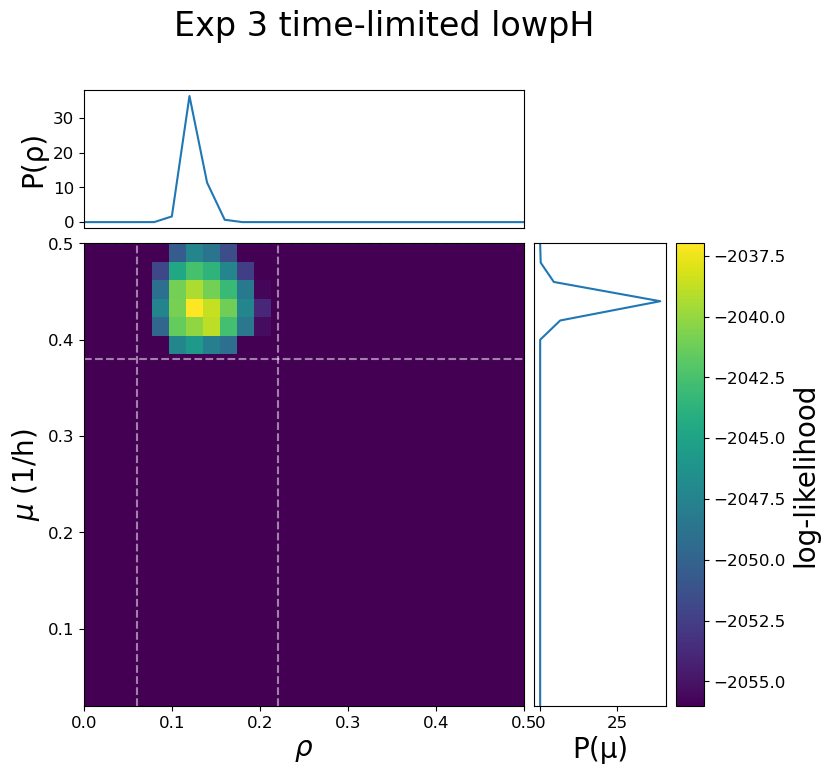

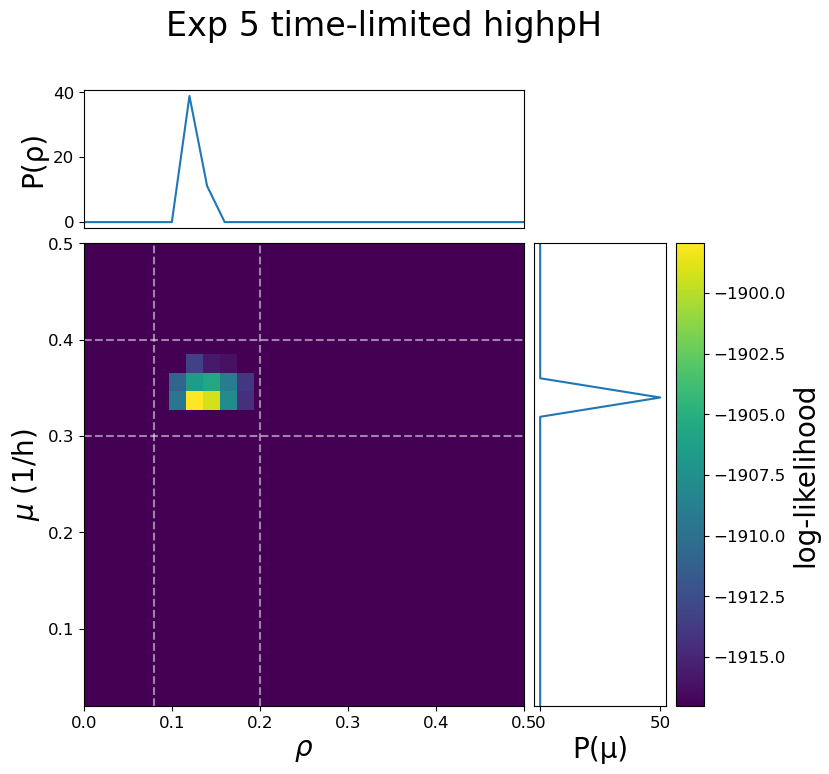

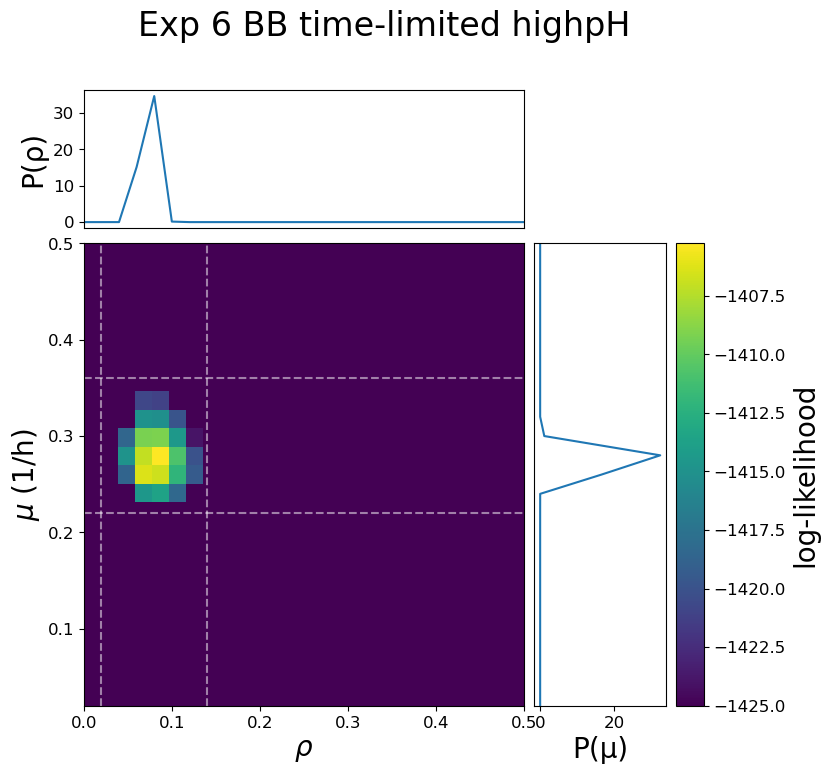

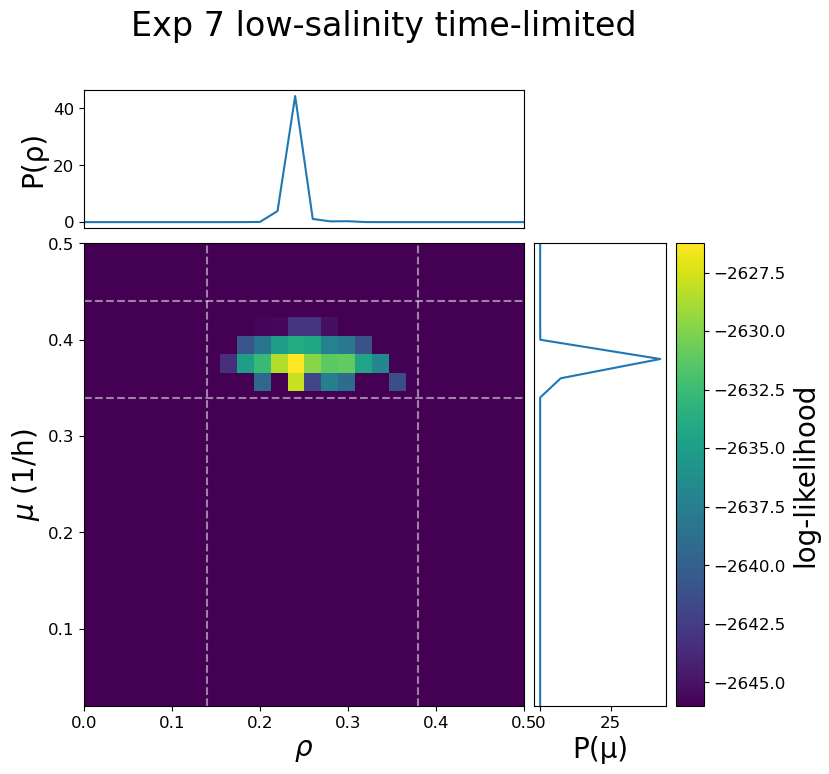

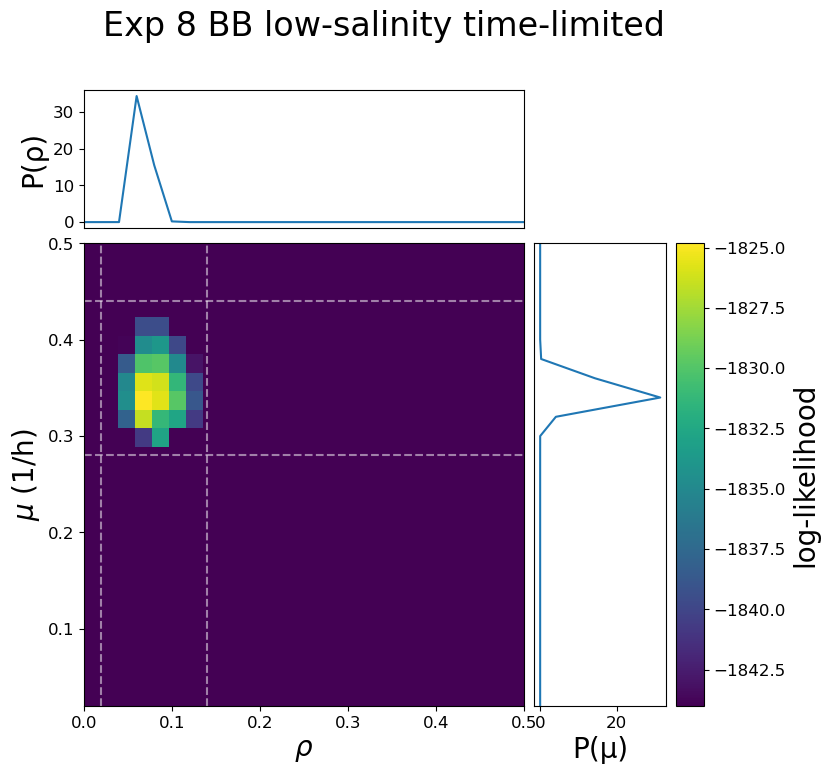

In [3]:

titles = ['Exp_2_reduced_live_lowpH', 'Exp_3_time-limited_lowpH', 'Exp_5_time-limited_highpH', 'Exp_6_BB_time-limited_highpH', 'Exp_7_low-salinity_time-limited', 'Exp_8_BB_low-salinity_time-limited']

#titles = [ 'Exp_3_time-limited_lowpH', 'Exp_5_time-limited_highpH', 'Exp_6_BB_time-limited_highpH', 'Exp_7_low-salinity_time-limited', 'Exp_8_BB_low-salinity_time-limited']

results = []


for title in titles:
    input = f"grid_likelihood_outputs/{title}/grid_zomega.csv"
    output = f"grid_likelihood_outputs/{title}/grid_zomega.png"

    df = pd.read_csv(input)
    df = df[df["mu"]<=.5]
    df = df[df["rho"]<=.5]

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    A = df["rho"].values.reshape(sh)
    M = df["mu"].values.reshape(sh)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min = int(np.max(Z)-20))  # normalize to get log-probabilities
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    results.append({
        "title": title,
        "mu_low": mus[r0],
        "mu_high": mus[r1], 
        "rho_low": rhos[c0],
        "rho_high": rhos[c1],
    })

    plt.rcParams.update({
        "font.size": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 20
    })

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu    = np.exp(Z_mu - np.log(mus[1] - mus[0]))
    # --- layout ---


    # --- layout with dedicated colorbar column ---
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        2, 3,
        width_ratios=[4, 1.2, 0.25],   # extra column for colorbar
        height_ratios=[1.2, 4],
        hspace=0.05,
        wspace=0.05
    )

    ax_top    = fig.add_subplot(gs[0, 0])
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_right  = fig.add_subplot(gs[1, 1])
    ax_cbar   = fig.add_subplot(gs[1, 2])  # colorbar axis

    # --- joint heatmap ---
    # im = ax_joint.pcolormesh(
    #     alphas,
    #     mus,
    #     Zeff.T,
    #     shading="auto"
    # )
    
    im = ax_joint.imshow(
        Zeff,
        extent=[rhos.min(), rhos.max(), mus.min(), mus.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlabel(r"$\rho$")
    ax_joint.set_ylabel(r"$\mu$ (1/h)")

    # --- colorbar in dedicated axis ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label("log-likelihood")

    # --- top marginal ---
    ax_top.plot(rhos, P_rho)
    ax_top.set_xlim(ax_joint.get_xlim())
    ax_top.set_xticks([])
    ax_top.set_ylabel("P(ρ)")

    # --- right marginal ---
    ax_right.plot(P_mu, mus)
    ax_right.set_ylim(ax_joint.get_ylim())
    ax_right.set_yticks([])
    ax_right.set_xlabel("P(μ)")

    ax_joint.axvline(rhos[c0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axvline(rhos[c1], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r1], color="white", linestyle="--",alpha=0.5)

    plt.suptitle(title.replace("_", " "))
    plt.tight_layout()

    plt.savefig(output, dpi=500)





/tmp/ipykernel_28552/3044216582.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_28552/3044216582.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


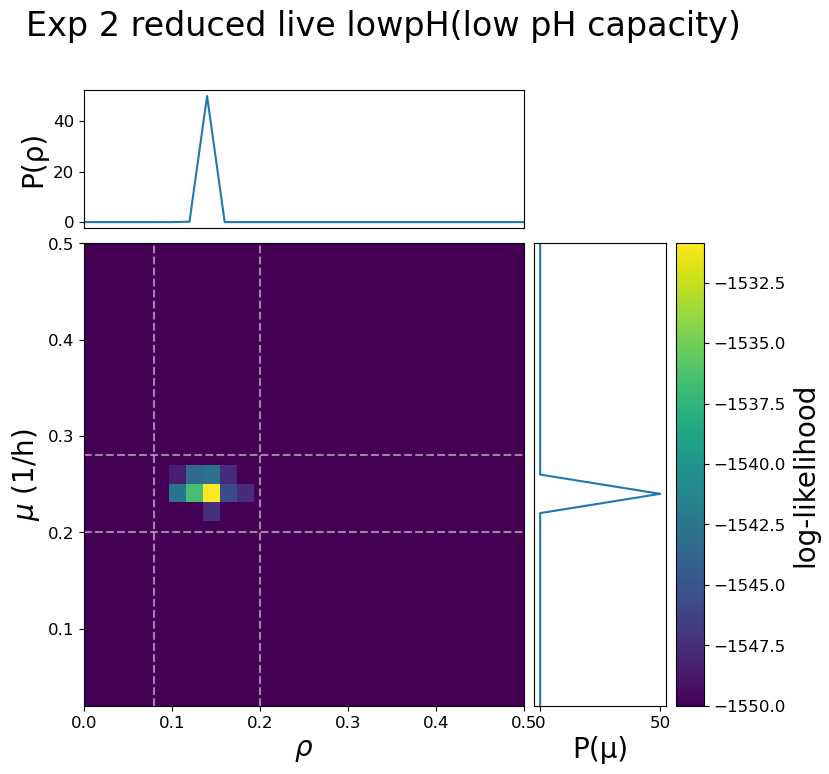

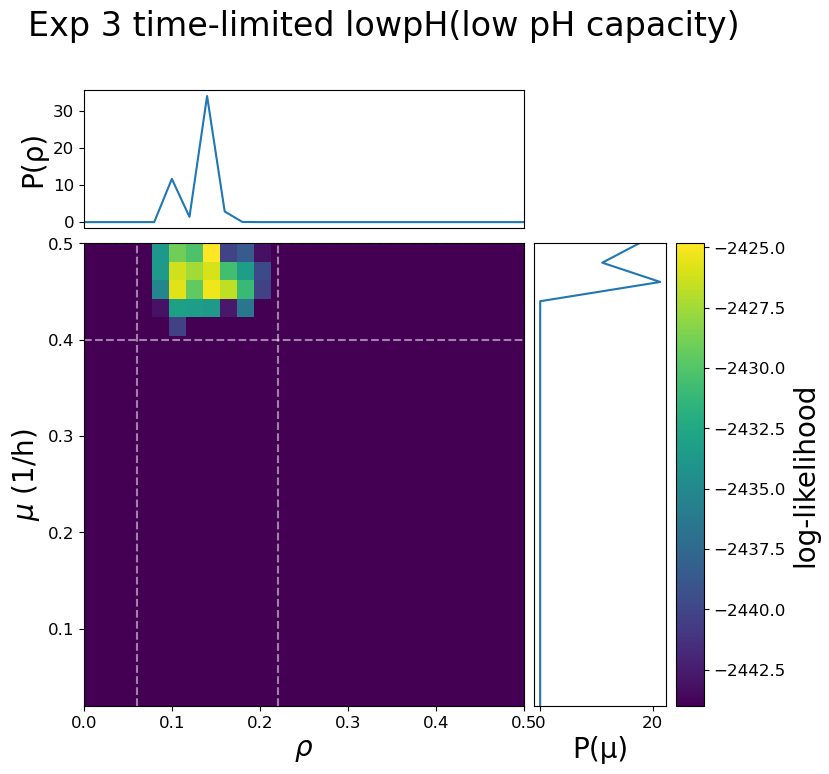

In [4]:

titles = ['Exp_2_reduced_live_lowpH', 'Exp_3_time-limited_lowpH']



for title in titles:
    input = f"grid_likelihood_outputs/{title}/grid_zomega_lowpH.csv"
    output = f"grid_likelihood_outputs/{title}/grid_zomega_lowpH.png"

    df = pd.read_csv(input)
    df = df[df["mu"]<=.5]
    df = df[df["rho"]<=.5]

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    A = df["rho"].values.reshape(sh)
    M = df["mu"].values.reshape(sh)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min = int(np.max(Z)-20))  # normalize to get log-probabilities
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    # results.append({
    #     "title": title,
    #     "mu_low": mus[r0],
    #     "mu_high": mus[r1], 
    #     "rho_low": rhos[c0],
    #     "rho_high": rhos[c1],
    # })

    plt.rcParams.update({
        "font.size": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 20
    })

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu    = np.exp(Z_mu - np.log(mus[1] - mus[0]))
    # --- layout ---


    # --- layout with dedicated colorbar column ---
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        2, 3,
        width_ratios=[4, 1.2, 0.25],   # extra column for colorbar
        height_ratios=[1.2, 4],
        hspace=0.05,
        wspace=0.05
    )

    ax_top    = fig.add_subplot(gs[0, 0])
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_right  = fig.add_subplot(gs[1, 1])
    ax_cbar   = fig.add_subplot(gs[1, 2])  # colorbar axis

    # --- joint heatmap ---
    # im = ax_joint.pcolormesh(
    #     alphas,
    #     mus,
    #     Zeff.T,
    #     shading="auto"
    # )
    
    im = ax_joint.imshow(
        Zeff,
        extent=[rhos.min(), rhos.max(), mus.min(), mus.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlabel(r"$\rho$")
    ax_joint.set_ylabel(r"$\mu$ (1/h)")

    # --- colorbar in dedicated axis ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label("log-likelihood")

    # --- top marginal ---
    ax_top.plot(rhos, P_rho)
    ax_top.set_xlim(ax_joint.get_xlim())
    ax_top.set_xticks([])
    ax_top.set_ylabel("P(ρ)")

    # --- right marginal ---
    ax_right.plot(P_mu, mus)
    ax_right.set_ylim(ax_joint.get_ylim())
    ax_right.set_yticks([])
    ax_right.set_xlabel("P(μ)")

    ax_joint.axvline(rhos[c0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axvline(rhos[c1], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r0], color="white", linestyle="--",alpha=0.5)
    ax_joint.axhline(mus[r1], color="white", linestyle="--",alpha=0.5)

    plt.suptitle(title.replace("_", " ")+'(low pH capacity)')
    plt.tight_layout()

    plt.savefig(output, dpi=500)





In [5]:
titles_1d = ['Exp_1_live_lowpH','Exp_4_live_highpH']
df_1d = [pd.read_csv(f"grid_likelihood_outputs/{title}/grid_zomega.csv") for title in titles_1d]


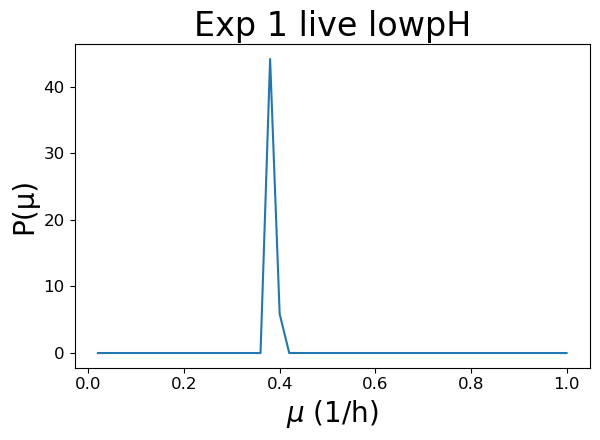

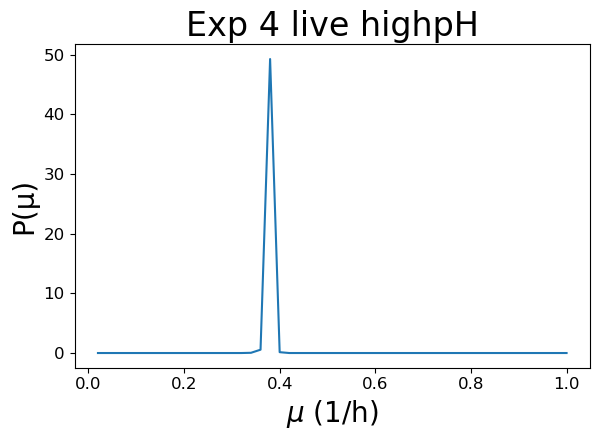

In [6]:
for title_1d in titles_1d:

    df_1d = pd.read_csv(f"grid_likelihood_outputs/{title_1d}/grid_zomega.csv")

    mu = df_1d["mu"].values
    loglike = df_1d["loglike"].values
    pmu = np.exp(loglike - logsumexp(loglike) - np.log(mu[1] - mu[0]))

    plt.plot(mu, pmu)
    plt.xlabel(r"$\mu$ (1/h)")
    plt.ylabel("P(μ)")
    plt.title(title_1d.replace("_", " "))
    plt.tight_layout()
    plt.savefig(f"grid_likelihood_outputs/{title_1d}/grid_zomega_1d.png", dpi=500)

    r0,r1 = crop_by_threshold(loglike, loglike.max() - 20)
    results.append({
        "title": title_1d,
        "mu_low": mu[r0],
        "mu_high": mu[r1],
    })
    plt.show()



In [7]:
df_cuts = pd.DataFrame(results)
df_cuts.to_csv("grid_likelihood_outputs/summary_cuts.csv", index=False)
#alphabetical order in title
df_cuts = df_cuts.sort_values("title")
df_cuts


,title,mu_low,mu_high,rho_low,rho_high
6,Exp_1_live_lowpH,0.38,0.42,NaN,NaN
0,Exp_2_reduced_live_lowpH,0.20,0.28,0.08,0.20
1,Exp_3_time-limited_lowpH,0.38,0.50,0.06,0.22
7,Exp_4_live_highpH,0.32,0.42,NaN,NaN
2,Exp_5_time-limited_highpH,0.30,0.40,0.08,0.20
3,Exp_6_BB_time-limited_highpH,0.22,0.36,0.02,0.14
4,Exp_7_low-salinity_time-limited,0.34,0.44,0.14,0.38
5,Exp_8_BB_low-salinity_time-limited,0.28,0.44,0.02,0.14


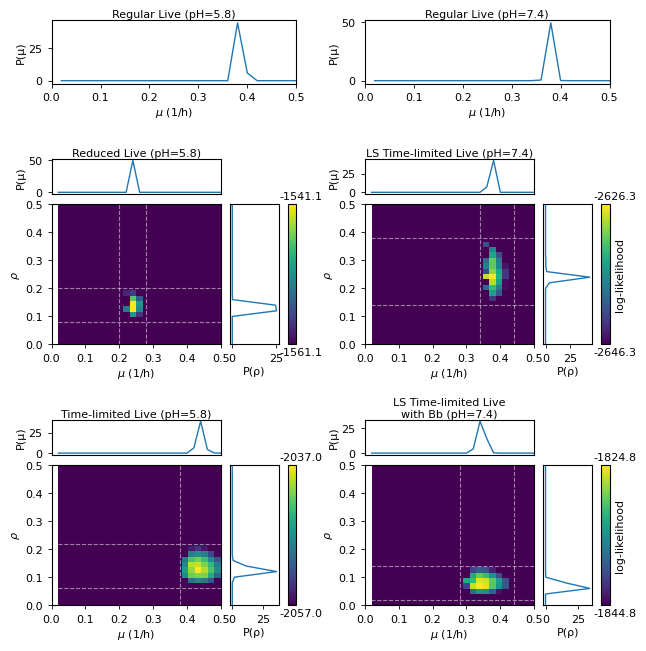

In [10]:
# Complete block for plotting purposes

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import logsumexp

def crop_by_threshold(A, val, pad=1):
    """
    Returns subarray that contains all entries >= val.
    Everything outside the returned subarray is guaranteed < val.

    pad: optional extra margin (in pixels) to keep around the box.
    """
    A = np.asarray(A)
    mask = A >= val

    if A.ndim != 2:
        cols = np.where(mask)[0]
        return cols[0], cols[-1]

    if mask.all():
        return (0, A.shape[0] - 1, 0, A.shape[1] - 1)

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]

    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(A.shape[0] - 1, r1 + pad)
    c1 = min(A.shape[1] - 1, c1 + pad)

    return r0, r1, c0, c1


plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 8,
})

results = []

top_titles = ['Exp_1_live_lowpH', 'Exp_4_live_highpH']
grid_titles = [
    'Exp_2_reduced_live_lowpH',
    'Exp_3_time-limited_lowpH',
    'Exp_7_low-salinity_time-limited',
    'Exp_8_BB_low-salinity_time-limited'
]

title_map = {
    'Exp_1_live_lowpH': 'Regular Live (pH=5.8)',
    'Exp_4_live_highpH': 'Regular Live (pH=7.4)',
    'Exp_2_reduced_live_lowpH': 'Reduced Live (pH=5.8)',
    'Exp_3_time-limited_lowpH': 'Time-limited Live (pH=5.8)',
    'Exp_7_low-salinity_time-limited': 'LS Time-limited Live (pH=7.4)',
    'Exp_8_BB_low-salinity_time-limited': 'LS Time-limited Live\nwith Bb (pH=7.4)',
}

fig = plt.figure(figsize=(7.2, 7.6))
outer = gridspec.GridSpec(
    3, 2, figure=fig,
    height_ratios=[1.2, 3.5, 3.5],
    wspace=0.28,
    hspace=0.52
)

# -----------------------------
# Top row: 1D panels
# -----------------------------
for col, title_1d in enumerate(top_titles):
    ax = fig.add_subplot(outer[0, col])

    df_1d = pd.read_csv(f"grid_likelihood_outputs/{title_1d}/grid_zomega.csv")
    df_1d = df_1d[df_1d["mu"] <= 0.5].copy()

    mu = df_1d["mu"].values
    loglike = df_1d["loglike"].values

    order = np.argsort(mu)
    mu = mu[order]
    loglike = loglike[order]

    loglike = np.nan_to_num(loglike, neginf=-1e6)

    dmu = mu[1] - mu[0]
    pmu = np.exp(loglike - logsumexp(loglike) - np.log(dmu))

    ax.plot(mu, pmu, lw=1.0)
    ax.set_xlim(0, 0.5)
    ax.set_xlabel(r"$\mu$ (1/h)", labelpad=2)
    ax.set_ylabel("P(μ)", labelpad=2)
    ax.set_title(title_map[title_1d], pad=2)
    ax.tick_params(direction="out", length=3, width=0.6)

# -----------------------------
# Lower rows: 2D panels
# -----------------------------
placement = {
    'Exp_2_reduced_live_lowpH': (1, 0),
    'Exp_3_time-limited_lowpH': (2, 0),
    'Exp_7_low-salinity_time-limited': (1, 1),
    'Exp_8_BB_low-salinity_time-limited': (2, 1),
}

for title in grid_titles:
    row, col = placement[title]

    df = pd.read_csv(f"grid_likelihood_outputs/{title}/grid_zomega.csv")
    df = df[(df["mu"] <= 0.5) & (df["rho"] <= 0.5)].copy()

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min=np.max(Z) - 20)
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu = np.exp(Z_mu - np.log(mus[1] - mus[0]))

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    results.append({
        "title": title,
        "mu_low": mus[r0],
        "mu_high": mus[r1],
        "rho_low": rhos[c0],
        "rho_high": rhos[c1],
    })

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 3,
        subplot_spec=outer[row, col],
        width_ratios=[4, 1.15, 0.20],
        height_ratios=[1.0, 4],
        hspace=0.12,
        wspace=0.12
    )

    ax_top = fig.add_subplot(inner[0, 0])
    ax_joint = fig.add_subplot(inner[1, 0])
    ax_right = fig.add_subplot(inner[1, 1])
    ax_cbar = fig.add_subplot(inner[1, 2])

    im = ax_joint.imshow(
        Zeff.T,
        extent=[mus.min(), mus.max(), rhos.min(), rhos.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlim(0, 0.5)
    ax_joint.set_ylim(0, 0.5)
    ax_joint.set_xlabel(r"$\mu$ (1/h)", labelpad=2)
    ax_joint.set_ylabel(r"$\rho$", labelpad=2)
    ax_joint.tick_params(direction="out", length=3, width=0.6)

    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.ax.tick_params(labelsize=8)

    vmin, vmax = im.get_clim()
    cbar = fig.colorbar(im, cax=ax_cbar)

    vmin, vmax = im.get_clim()

    # remove default ticks
    cbar.set_ticks([])

    # add manual labels above and below
    ax_cbar.text(
        1.6, 1.02, f"{vmax:.1f}",
        ha="center", va="bottom",
        transform=ax_cbar.transAxes,
        fontsize=8
    )

    ax_cbar.text(
        1.6, -0.02, f"{vmin:.1f}",
        ha="center", va="top",
        transform=ax_cbar.transAxes,
        fontsize=8
    )

    if title in [
        "Exp_7_low-salinity_time-limited",
        "Exp_8_BB_low-salinity_time-limited"
    ]:
        cbar.set_label("log-likelihood", fontsize=8, labelpad=4)

    ax_top.plot(mus, P_mu, lw=1.0)
    ax_top.set_xlim(0, 0.5)
    ax_top.set_xticks([])
    ax_top.set_ylabel("P(μ)", labelpad=2)
    ax_top.set_title(title_map[title], pad=2)
    ax_top.tick_params(direction="out", length=3, width=0.6)

    ax_right.plot(P_rho, rhos, lw=1.0)
    ax_right.set_ylim(0, 0.5)
    ax_right.set_yticks([])
    ax_right.set_xlabel("P(ρ)", labelpad=2)
    ax_right.tick_params(direction="out", length=3, width=0.6)

    # Threshold boxes
    ax_joint.axvline(mus[r0], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axvline(mus[r1], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axhline(rhos[c0], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axhline(rhos[c1], color="white", linestyle="--", alpha=0.5, lw=0.8)

plt.savefig(
    "grid_likelihood_outputs/combined_exp1_4_2_3_7_8.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()